In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms

In [12]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), 
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_val_dataset = datasets.FashionMNIST(
    root='data', train=True, download=False, transform=transform
 )
test_dataset = datasets.FashionMNIST(
    root='data', train=False, download=False, transform=transform
 )

class_names = train_val_dataset.classes
print(class_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [13]:
train_size = int(0.8 * len(train_val_dataset))
val_size = len(train_val_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    train_val_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
 )

batch_size = 32
num_workers = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

In [14]:
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 20*20)
        self.fc2 = nn.Linear(20*20, 15*15)
        self.fc3 = nn.Linear(15*15, 8*8)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        
        return x 

enc = Encoder()
print(enc)

Encoder(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc2): Linear(in_features=400, out_features=225, bias=True)
  (fc3): Linear(in_features=225, out_features=64, bias=True)
  (relu): ReLU()
)


In [15]:
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(8*8, 15*15)
        self.fc2 = nn.Linear(15*15, 20*20)
        self.fc3 = nn.Linear(20*20, 28*28)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))

        return x

dec = Decoder()
print(dec)

Decoder(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=64, out_features=225, bias=True)
  (fc2): Linear(in_features=225, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=784, bias=True)
  (relu): ReLU()
)


In [16]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = enc
        self.decoder = dec

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)

        x = x.view(-1, 1, 28, 28)
        return x

In [17]:
model = Autoencoder()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []

epochs = 20

device = "cuda"
model.to(device)

Autoencoder(
  (encoder): Encoder(
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (fc1): Linear(in_features=784, out_features=400, bias=True)
    (fc2): Linear(in_features=400, out_features=225, bias=True)
    (fc3): Linear(in_features=225, out_features=64, bias=True)
    (relu): ReLU()
  )
  (decoder): Decoder(
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (fc1): Linear(in_features=64, out_features=225, bias=True)
    (fc2): Linear(in_features=225, out_features=400, bias=True)
    (fc3): Linear(in_features=400, out_features=784, bias=True)
    (relu): ReLU()
  )
)

In [18]:
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for images, _ in train_loader: 
        images = images.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
    
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, _ in val_loader:
            images = images.to(device)
            outputs = model(images)
            loss = criterion(outputs, images)
            val_loss += loss.item() * images.size(0)
    
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}] -> Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

print("Training complete!")

Epoch [1/20] -> Train Loss: 0.6260, Val Loss: 0.6165
Epoch [2/20] -> Train Loss: 0.6141, Val Loss: 0.6107
Epoch [3/20] -> Train Loss: 0.6102, Val Loss: 0.6083
Epoch [4/20] -> Train Loss: 0.6083, Val Loss: 0.6064
Epoch [5/20] -> Train Loss: 0.6069, Val Loss: 0.6058
Epoch [6/20] -> Train Loss: 0.6057, Val Loss: 0.6044
Epoch [7/20] -> Train Loss: 0.6048, Val Loss: 0.6037
Epoch [8/20] -> Train Loss: 0.6040, Val Loss: 0.6032
Epoch [9/20] -> Train Loss: 0.6036, Val Loss: 0.6026
Epoch [10/20] -> Train Loss: 0.6034, Val Loss: 0.6027
Epoch [11/20] -> Train Loss: 0.6033, Val Loss: 0.6025
Epoch [12/20] -> Train Loss: 0.6031, Val Loss: 0.6026
Epoch [13/20] -> Train Loss: 0.6029, Val Loss: 0.6022
Epoch [14/20] -> Train Loss: 0.6027, Val Loss: 0.6022
Epoch [15/20] -> Train Loss: 0.6025, Val Loss: 0.6018
Epoch [16/20] -> Train Loss: 0.6022, Val Loss: 0.6017
Epoch [17/20] -> Train Loss: 0.6021, Val Loss: 0.6015
Epoch [18/20] -> Train Loss: 0.6020, Val Loss: 0.6016
Epoch [19/20] -> Train Loss: 0.6018, 

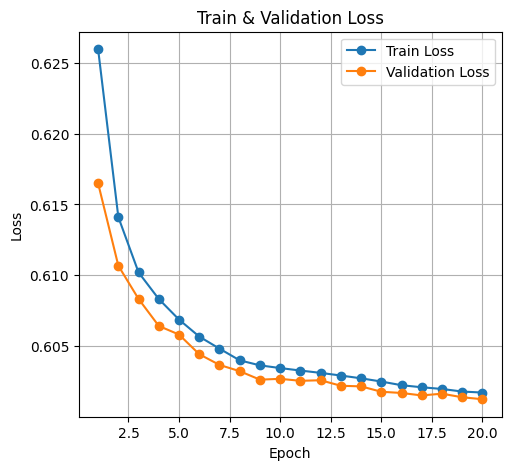

In [20]:
epochs_range = range(1, epochs + 1)

# Plot Losses
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss', marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', marker='o')
plt.title('Train & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

In [25]:
model.eval()

test_loss = 0

with torch.no_grad():
    for images, _ in train_loader:
        images = images.to(device)
        outputs = model(images)
        loss = criterion(outputs, images)
        test_loss += loss.item() * images.size(0)

print(test_loss/len(test_loader.dataset))

2.8871167377471925


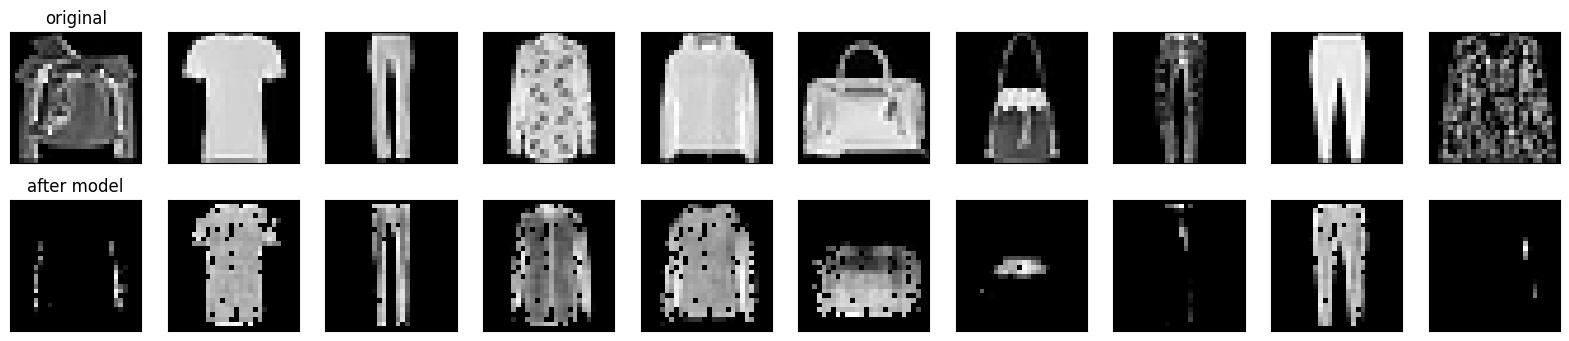

In [26]:
model.eval()

data_iter = iter(val_loader)  
images, _ = next(data_iter)
images = images.to(device)

with torch.no_grad():
    outputs = model(images)

images = images.cpu()
outputs = outputs.cpu()

num_images = 10
plt.figure(figsize=(20, 4))
for i in range(num_images):
    # Original image
    ax = plt.subplot(2, num_images, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("original")

    # Reconstructed image
    ax = plt.subplot(2, num_images, i + 1 + num_images)
    plt.imshow(outputs[i].squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("after model")

plt.show()

it looks like maybe my compression was too high, as smaller details and darker get lost easily. however, bright area and the general shapes are generally visible. 